# `kamo.scattering` demo -- K39 s-wave scattering length $a(B)$

Complex s-wave scattering length $a(B)$ for a colliding pair of $^{39}$K
$4S_{1/2}$ ground-state atoms vs magnetic field, for the low-field target
channels $|1,-1\rangle$, $|1,0\rangle$, $|1,+1\rangle$.

Cross-checks the empirical model against the **Kokkelmans coupled-channels
reference** built into the K39 module (`Potassium39.get_scattering_length`:
`aa`=$|1,1\rangle$, `bb`=$|1,0\rangle$, `cc`=$|1,-1\rangle$).

Empirical parameters are literature-verified (Etrych 2023 / Chapurin 2019 /
Falke 2008 / D'Errico 2007).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
%load_ext autoreload
%autoreload 2

plt.rcParams['figure.dpi'] = 130
plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['image.cmap'] = 'magma'

from kamo import Potassium39
from kamo.scattering import ScatteringModel, k2_from_scattering_length
from kamo.scattering import units as u
from kamo.scattering.data import k39_params as kp

model = ScatteringModel(B_max=1000.0)
atom = Potassium39()

TARGETS = [(1, -1), (1, 0), (1, 1)]
COLORS  = {(1, -1): 'C0', (1, 0): 'C1', (1, 1): 'C2'}
def lbl(s): return f"|1,{s[1]:+d}>"
print("params verified:", kp.PARAMS_VERIFIED)

params verified: True


## 1. Reference constants and van der Waals lengths

In [ ]:
a_S, a_T, C6 = kp.singlet_triplet()
print(f"singlet a_S = {a_S:.2f} +/- {kp.A_SINGLET_UNC_A0} a0   (Falke 2008)")
print(f"triplet a_T = {a_T:.2f} +/- {kp.A_TRIPLET_UNC_A0} a0   (Falke 2008)")
print(f"C6          = {C6:.0f} +/- {kp.C6_UNC_AU} a.u.        (D'Errico 2007)")
print(f"R_vdW       = {u.vdw_length_a0(C6)/2:.2f} a0           (expect ~64.6)")
print(f"a-bar       = {u.mean_scattering_length_a0(C6):.2f} a0           (expect ~61.8)")

singlet a_S = 138.49 +/- 0.12 a0   (Falke 2008)
triplet a_T = -33.48 +/- 0.18 a0   (Falke 2008)
C6          = 3921 +/- 8.0 a.u.        (D'Errico 2007)


R_vdW       = 64.59 a0           (expect ~64.6)
a-bar       = 61.75 a0           (expect ~61.8)


## 2. $a(B)$ for the target channels

Empirical multi-resonance product form
$a(B) = a_\mathrm{bg}\prod_i (1 - \Delta_i/(B-B_{0,i}))$.

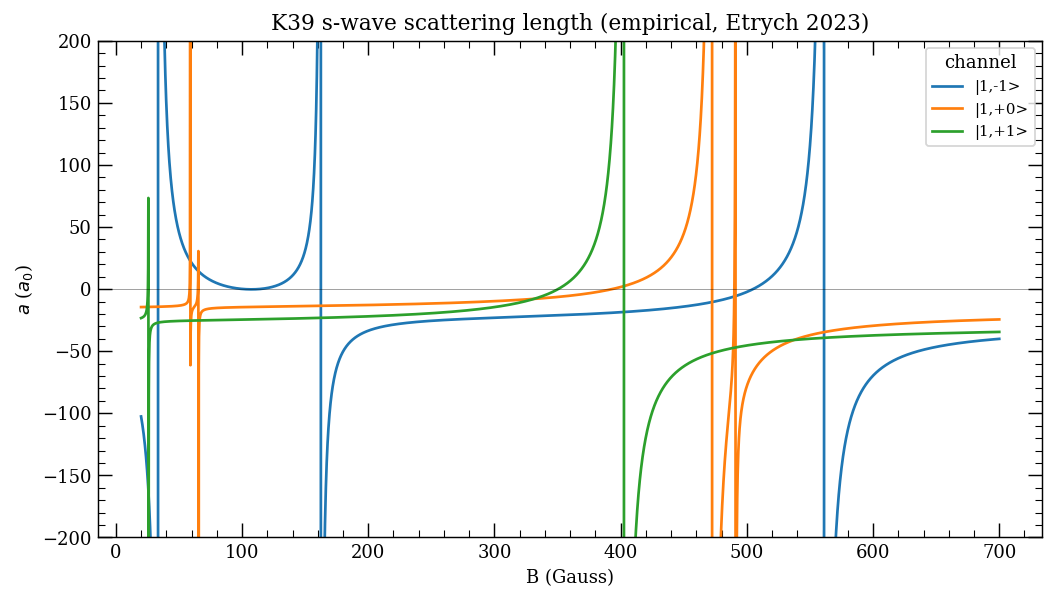

In [ ]:
B = np.linspace(20, 700, 4000)
fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
for s in TARGETS:
    ax.plot(B, np.real(model.intra(s, B)), color=COLORS[s], label=lbl(s))
ax.axhline(0, color='k', lw=0.5, alpha=0.4)
ax.set(xlabel='B (Gauss)', ylabel=r'$a$ ($a_0$)', ylim=(-200, 200),
       title='K39 s-wave scattering length (empirical, Etrych 2023)')
ax.legend(title='channel')

## 3. Compare to the Kokkelmans coupled-channels reference

`atom.get_scattering_length(F, mF, B)` loads the Kokkelmans coupled-channels
$a(B)$ built into the K39 module. Overlay + residuals -- an **independent** full
multichannel calculation, so agreement validates the empirical model.
*(Skipped gracefully if the `B:` data drive is not mounted.)*

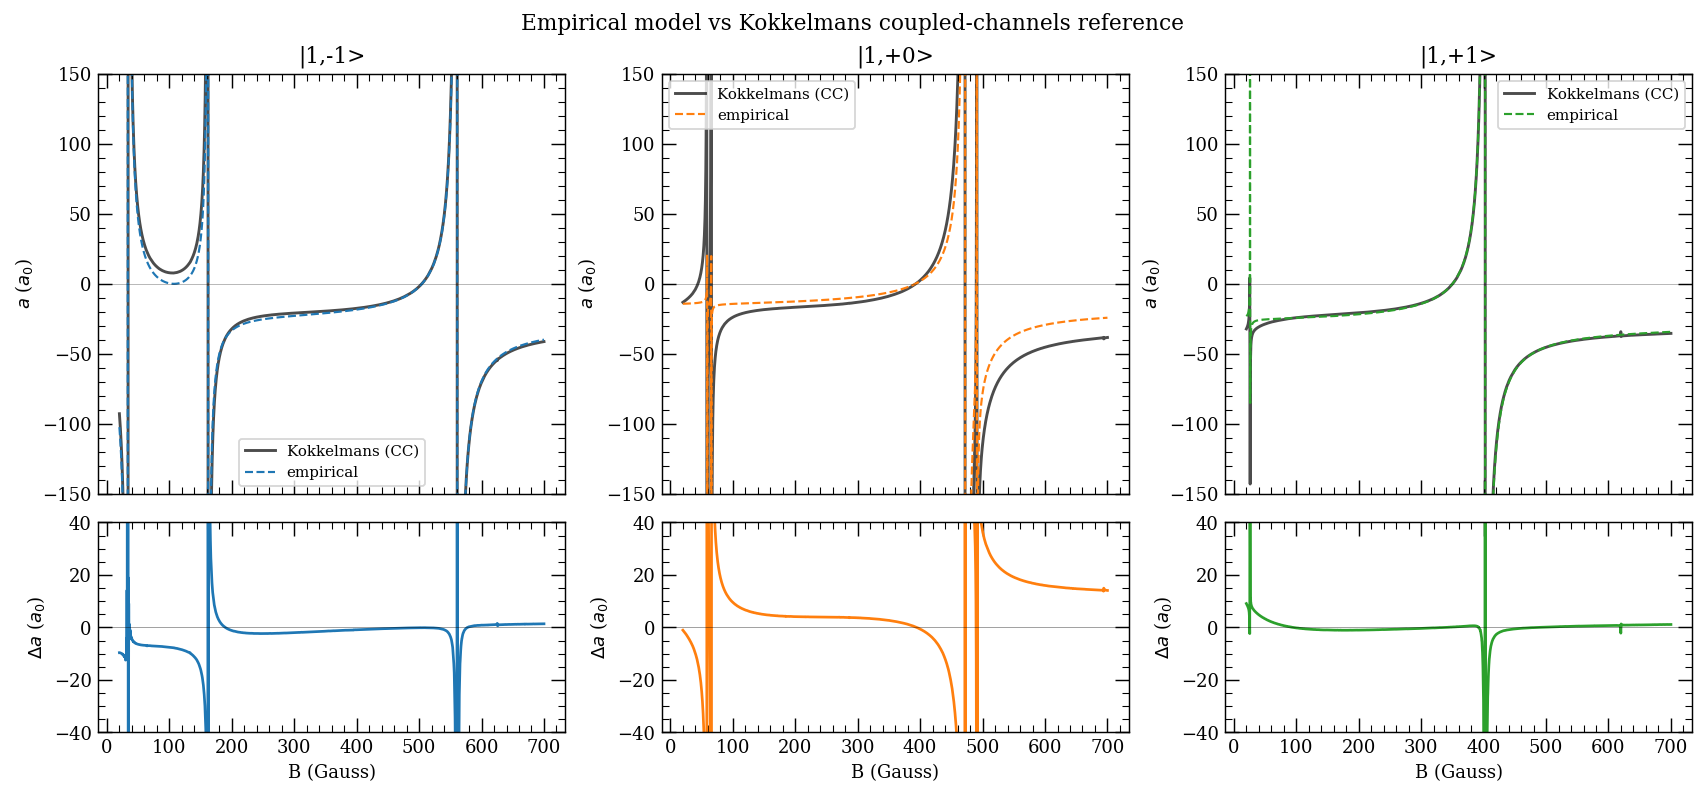

In [ ]:
B = np.linspace(20, 700, 3000)
try:
    kok = {s: np.real(atom.get_scattering_length(s[0], s[1], B, interp=True)) for s in TARGETS}
    KOK_OK = True
except Exception as e:
    KOK_OK = False
    print("Kokkelmans reference unavailable (B: drive?):", e)
if KOK_OK:
    fig, axes = plt.subplots(2, 3, figsize=(13, 6), layout='constrained',
                             sharex=True, height_ratios=[2, 1])
    for k, s in enumerate(TARGETS):
        mine = np.real(model.intra(s, B))
        axes[0, k].plot(B, kok[s], 'k', lw=1.6, alpha=0.7, label='Kokkelmans (CC)')
        axes[0, k].plot(B, mine, color=COLORS[s], lw=1.2, ls='--', label='empirical')
        axes[0, k].axhline(0, color='k', lw=0.5, alpha=0.3)
        axes[0, k].set(title=lbl(s), ylim=(-150, 150), ylabel=r'$a$ ($a_0$)')
        axes[0, k].legend()
        axes[1, k].plot(B, mine - kok[s], color=COLORS[s])
        axes[1, k].axhline(0, color='k', lw=0.5, alpha=0.4)
        axes[1, k].set(xlabel='B (Gauss)', ylabel=r'$\Delta a$ ($a_0$)', ylim=(-40, 40))
    fig.suptitle('Empirical model vs Kokkelmans coupled-channels reference')

Close agreement for $|1,-1\rangle$ and $|1,+1\rangle$. The larger residual
for $|1,0\rangle$ near 50--70 G is expected: those two narrow resonances (58.97,
65.57 G) have **estimated** widths (flagged `verified=False`).

In [ ]:
if KOK_OK:
    for s in TARGETS:
        res_B = [r.B0_gauss for r in model.resonances(s, s)]
        mask = np.all([np.abs(B - b0) > 3.0 for b0 in res_B], axis=0)
        mine = np.real(model.intra(s, B))
        rms = np.sqrt(np.nanmean((mine[mask] - kok[s][mask])**2))
        print(f"{lbl(s)}: RMS(empirical - Kokkelmans) away from poles = {rms:5.2f} a0")

|1,-1>: RMS(empirical - Kokkelmans) away from poles =  5.81 a0
|1,+0>: RMS(empirical - Kokkelmans) away from poles = 22.93 a0
|1,+1>: RMS(empirical - Kokkelmans) away from poles =  2.39 a0


## 4. Resonances and zero-crossings (literature-verified)

In [ ]:
for s in TARGETS:
    print(f"--- {lbl(s)} ---")
    for r in model.resonances(s, s):
        flag = "" if r.verified else "  (Delta estimated)"
        print(f"   B0 = {r.B0_gauss:8.3f} G   Delta = {r.width_gauss:+8.2f} G{flag}")
    zc = model.zero_crossings(s, s)
    if zc:
        vals = [round(float(np.real(model.intra(s, b))), 3) for b in zc]
        print(f"   zero-crossings: {zc} G  -> a(B_zero) = {vals}")

--- |1,-1> ---
   B0 =   33.582 G   Delta =   +79.47 G
   B0 =  162.360 G   Delta =   -60.63 G
   B0 =  561.140 G   Delta =   -56.24 G
   zero-crossings: [504.9] G  -> a(B_zero) = [-0.0]
--- |1,+0> ---
   B0 =   58.970 G   Delta =    -0.50 G  (Delta estimated)
   B0 =   65.570 G   Delta =    -0.50 G  (Delta estimated)
   B0 =  472.330 G   Delta =   -79.13 G
   B0 =  491.170 G   Delta =    -1.07 G
   zero-crossings: [393.2, 490.1] G  -> a(B_zero) = [-0.0, -0.0]
--- |1,+1> ---
   B0 =   25.910 G   Delta =    -0.50 G  (Delta estimated)
   B0 =  402.740 G   Delta =   -52.34 G
   B0 =  752.300 G   Delta =    -0.40 G  (Delta estimated)
   zero-crossings: [350.4] G  -> a(B_zero) = [-0.0]


## 5. Differential scattering length and two-body loss

Decoherence driver = **differential elastic** scattering length
$a_{|1,-1\rangle} - a_{|1,0\rangle}$. All three targets are elastic at threshold
(`is_lossy` False): no open $M_F$-conserving spin-exchange channel below them.

|1,-1>: is_lossy @ [60,200,400] G -> [False, False, False]
|1,+0>: is_lossy @ [60,200,400] G -> [False, False, False]


|1,+1>: is_lossy @ [60,200,400] G -> [False, False, False]


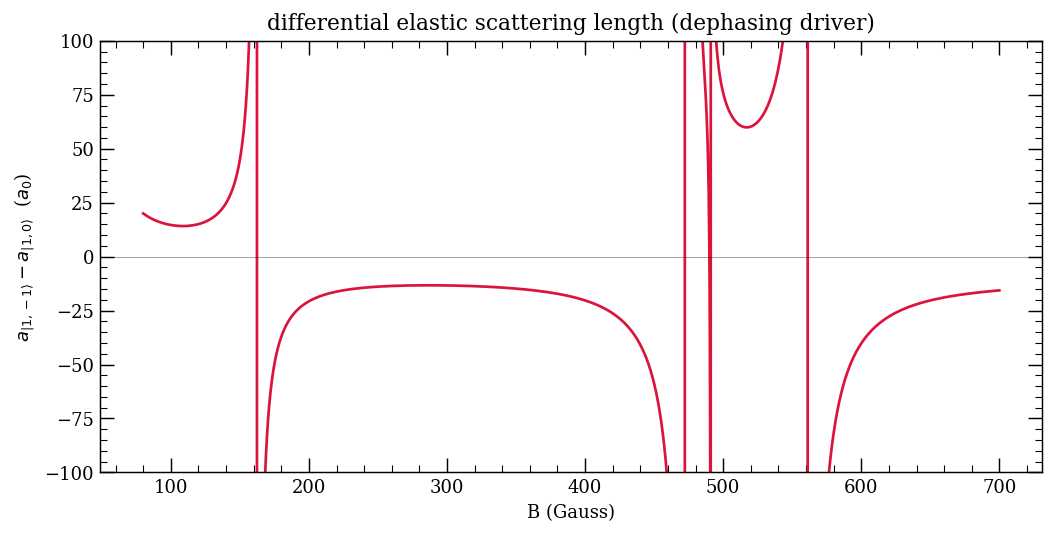

In [ ]:
B = np.linspace(80, 700, 3000)
da = np.real(model.intra((1, -1), B)) - np.real(model.intra((1, 0), B))
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
ax.plot(B, da, color='crimson'); ax.axhline(0, color='k', lw=0.5, alpha=0.4)
ax.set(xlabel='B (Gauss)', ylabel=r'$a_{|1,-1\rangle}-a_{|1,0\rangle}$  ($a_0$)',
       ylim=(-100, 100), title='differential elastic scattering length (dephasing driver)')

for s in TARGETS:
    print(f"{lbl(s)}: is_lossy @ [60,200,400] G ->",
          [model.is_lossy(s, s, b) for b in (60., 200., 400.)])

## 6. Singlet/triplet content and the frame transform

Pure angular-momentum bookkeeping (no fitted parameters), verified two ways:
direct projection vs the electron-spin frame transform used by the MQDT backend.

In [ ]:
from kamo.scattering.channels import PairChannel, singlet_triplet_fractions
from kamo.scattering.backends.mqdt import MQDTBackend
mq = MQDTBackend()
print(f"{'channel':16s} {'f_S':>7s} {'f_T':>7s}  {'fS(frame)':>10s}  match")
for s in TARGETS + [(2, 2)]:
    c = PairChannel(s, s)
    fS, fT = singlet_triplet_fractions(c)
    fS2 = mq.singlet_fraction_via_frame(c)
    print(f"{lbl(s)+'+'+lbl(s):16s} {fS:7.4f} {fT:7.4f}  {fS2:10.4f}  {abs(fS-fS2)<1e-9}")

channel              f_S     f_T   fS(frame)  match
|1,-1>+|1,-1>     0.1875  0.8125      0.1875  True
|1,+0>+|1,+0>     0.2500  0.7500      0.2500  True
|1,+1>+|1,+1>     0.1875  0.8125      0.1875  True
|1,+2>+|1,+2>     0.0000  1.0000      0.0000  True


### Notes / caveats
- Empirical resonance parameters are literature-verified; two secondary
  $|1,0\rangle$ widths (58.97, 65.57 G) are estimated (`verified=False`).
- The mixed inter-channel $|1,-1\rangle+|1,0\rangle$ is not tabulated in the
  literature (left out; elastic at threshold anyway).
- The MQDT frame transform is validated (section 6); its multichannel $a(B)$ is
  gated pending the Xie et al. short-range parameters.
- Complex $a$ / two-body loss $K_2$ apply to genuinely open-loss channels; the
  $F=1$ targets are elastic.